In [1]:
import pandas as pd

df = pd.read_csv("movies.csv")  # tai sep=";" jos puolipiste
print(df.head())
print(df.columns)


     movie_id            title     content_type genre_primary genre_secondary  \
0  movie_0001    Dragon Legend  Stand-up Comedy       History        Thriller   
1  movie_0002    Storm Warrior  Stand-up Comedy        Sci-Fi             NaN   
2  movie_0003      Fire Family            Movie         Drama             NaN   
3  movie_0004     Our Princess      Documentary        Sci-Fi             NaN   
4  movie_0005  Warrior Mission      Documentary         Sport         Mystery   

   release_year  duration_minutes rating  language country_of_origin  \
0          2014              35.0   TV-Y    French             Japan   
1          2017              37.0     PG  Japanese               USA   
2          2003             142.0  TV-MA   English               USA   
3          2011             131.0  NC-17  Japanese               USA   
4          2015              91.0   TV-G   English               USA   

   imdb_rating  production_budget  box_office_revenue  number_of_seasons  \
0   

In [2]:
import pandas as pd
df = pd.read_csv("movies.csv")
print(df.columns)


Index(['movie_id', 'title', 'content_type', 'genre_primary', 'genre_secondary',
       'release_year', 'duration_minutes', 'rating', 'language',
       'country_of_origin', 'imdb_rating', 'production_budget',
       'box_office_revenue', 'number_of_seasons', 'number_of_episodes',
       'is_netflix_original', 'added_to_platform', 'content_warning'],
      dtype='str')


In [3]:
import pandas as pd

df = pd.read_csv("movies.csv")

# Yhdistä genre_primary ja genre_secondary listaksi
df["genres"] = df[["genre_primary", "genre_secondary"]].values.tolist()

# Poista NaN listasta
df["genres"] = df["genres"].apply(lambda x: [g for g in x if pd.notna(g)])

# Poista alkuperäiset sarakkeet
df = df.drop(columns=["genre_primary", "genre_secondary"])

# Vie JSONiksi
df.to_json("movies.json", orient="records", indent=2)


In [41]:
#Tässä kohtaa pitäisi siirtää movies.json MongoDB:hen, esimerkiksi MongoDB Compass -työkalulla. TEHTY luomalla uusi tietokanta ja lisäämällä json-tiedosto

In [42]:
# from pyspark.sql import SparkSession
# import pymongo

# # Initialize Spark session
# spark = SparkSession.builder.appName("MongoDBLab").getOrCreate()

# # Connect to MongoDB and fetch data
# client = pymongo.MongoClient("mongodb://localhost:27017/")
# db = client["Movies"]
# collection = db["Films"]
# data = list(collection.find())



# # Convert to Spark DataFrame (excluding '_id')
# data = [{k: v for k, v in doc.items() if k != "_id"} for doc in data]
# df = spark.createDataFrame(data)

# # Show schema and data
# df.printSchema()
# df.show()

In [4]:
from pyspark.sql import SparkSession
import pymongo
import math

# Initialize Spark session
spark = SparkSession.builder.appName("MongoDBLab").getOrCreate()

# Connect to MongoDB and fetch data
client = pymongo.MongoClient("mongodb://localhost:27017/")
db = client["Movies"]
collection = db["Films"]
data = list(collection.find())

# Convert MongoDB documents to Python dicts without _id
cleaned = []
for doc in data:
    new_doc = {k: v for k, v in doc.items() if k != "_id"}

    # Force numeric fields to float (DoubleType in Spark)
    numeric_fields = [
        "imdb_rating",
        "production_budget",
        "box_office_revenue",
        "duration_minutes",
        "number_of_seasons",
        "number_of_episodes"
    ]

    for field in numeric_fields:
        value = new_doc.get(field)
        if value is None:
            new_doc[field] = None
        else:
            try:
                new_doc[field] = float(value)
            except:
                new_doc[field] = None

    cleaned.append(new_doc)

# Create Spark DataFrame
df = spark.createDataFrame(cleaned)

# 2. Suodata vain elokuvat
df = df.filter(df.content_type == "Movie")

df = df.dropDuplicates()


# Show schema and data
df.printSchema()
df.show()


root
 |-- added_to_platform: string (nullable = true)
 |-- box_office_revenue: double (nullable = true)
 |-- content_type: string (nullable = true)
 |-- content_warning: boolean (nullable = true)
 |-- country_of_origin: string (nullable = true)
 |-- duration_minutes: double (nullable = true)
 |-- genres: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- imdb_rating: double (nullable = true)
 |-- is_netflix_original: boolean (nullable = true)
 |-- language: string (nullable = true)
 |-- movie_id: string (nullable = true)
 |-- number_of_episodes: double (nullable = true)
 |-- number_of_seasons: double (nullable = true)
 |-- production_budget: double (nullable = true)
 |-- rating: string (nullable = true)
 |-- release_year: long (nullable = true)
 |-- title: string (nullable = true)

+-----------------+------------------+------------+---------------+-----------------+----------------+-------------------+-----------+-------------------+--------+----------+-------

In [44]:
# df.printSchema()
# df.show()


In [5]:
# Register DataFrame as a temporary table
df.createOrReplaceTempView("films")

# Spark SQL: Calculate average score
top10_sql = spark.sql("""
    SELECT
        title,
        content_type,
        release_year,
        imdb_rating,
        genres
    FROM films
    WHERE imdb_rating IS NOT NULL
        AND content_type = 'Movie'                  
    ORDER BY imdb_rating DESC
    LIMIT 10
""")


# Show transformed data
top10_sql.show(truncate=False)



+-------------+------------+------------+-----------+--------------------+
|title        |content_type|release_year|imdb_rating|genres              |
+-------------+------------+------------+-----------+--------------------+
|My Story     |Movie       |1993        |10.0       |[Horror]            |
|Last Night   |Movie       |2000        |10.0       |[Western, Biography]|
|Our Night    |Movie       |2015        |10.0       |[History]           |
|Dream Warrior|Movie       |1998        |10.0       |[Romance, Action]   |
|Storm Mystery|Movie       |2019        |10.0       |[Comedy]            |
|Story Warrior|Movie       |1998        |10.0       |[Music]             |
|Bright War   |Movie       |1997        |9.9        |[Crime, Sci-Fi]     |
|City Queen   |Movie       |2020        |9.7        |[History, Biography]|
|Love Fire    |Movie       |2022        |9.5        |[Documentary]       |
|Dragon Day   |Movie       |2005        |9.5        |[Sport]             |
+-------------+----------

In [6]:
# transformed_data = transformed_df.toPandas().to_dict("records")
# output_collection = db["students_transformed"]
# output_collection.drop()
# output_collection.insert_many(transformed_data)

# Valitse Spark DataFrame (esim. IMDb Top 10)
transformed_df = top10_sql

# Muunna MongoDB:lle sopivaksi
transformed_data = transformed_df.toPandas().to_dict("records")

# Tallenna uuteen kokoelmaan
output_collection = db["Films_transformed"]
output_collection.drop()
output_collection.insert_many(transformed_data)


InsertManyResult([ObjectId('69d3a37b6a18a0822e4a2b50'), ObjectId('69d3a37b6a18a0822e4a2b51'), ObjectId('69d3a37b6a18a0822e4a2b52'), ObjectId('69d3a37b6a18a0822e4a2b53'), ObjectId('69d3a37b6a18a0822e4a2b54'), ObjectId('69d3a37b6a18a0822e4a2b55'), ObjectId('69d3a37b6a18a0822e4a2b56'), ObjectId('69d3a37b6a18a0822e4a2b57'), ObjectId('69d3a37b6a18a0822e4a2b58'), ObjectId('69d3a37b6a18a0822e4a2b59')], acknowledged=True)

In [7]:
top10 = df.orderBy(df.imdb_rating.desc()).limit(10)
top10.show()


+-----------------+------------------+------------+---------------+-----------------+----------------+--------------------+-----------+-------------------+--------+----------+------------------+-----------------+-----------------+------+------------+-------------+
|added_to_platform|box_office_revenue|content_type|content_warning|country_of_origin|duration_minutes|              genres|imdb_rating|is_netflix_original|language|  movie_id|number_of_episodes|number_of_seasons|production_budget|rating|release_year|        title|
+-----------------+------------------+------------+---------------+-----------------+----------------+--------------------+-----------+-------------------+--------+----------+------------------+-----------------+-----------------+------+------------+-------------+
|       2023-09-10|       1.1553135E7|       Movie|          false|              USA|            94.0|            [Horror]|       10.0|              false| Spanish|movie_0172|              NULL|           

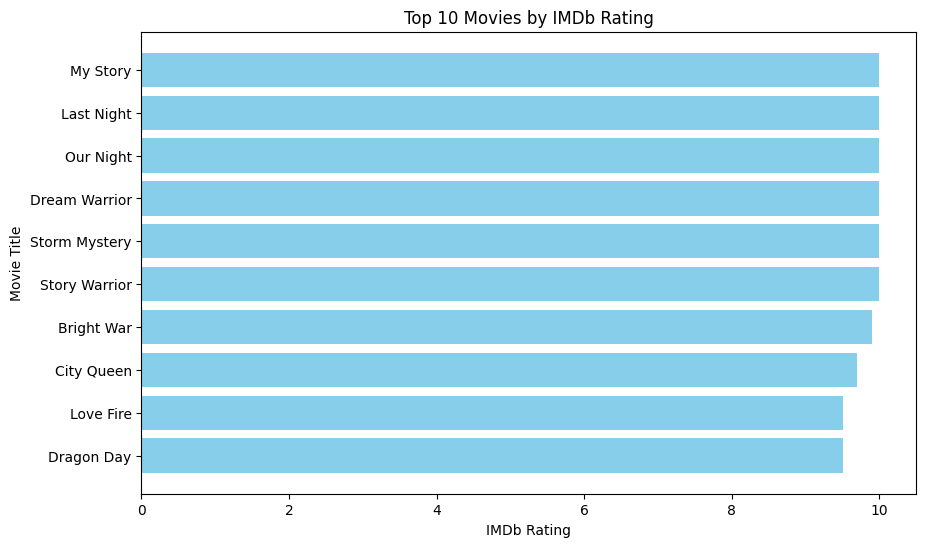

In [8]:
pdf = top10.toPandas()
pdf
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.barh(pdf["title"], pdf["imdb_rating"], color="skyblue")
plt.xlabel("IMDb Rating")
plt.ylabel("Movie Title")
plt.title("Top 10 Movies by IMDb Rating")
plt.gca().invert_yaxis()
plt.show()


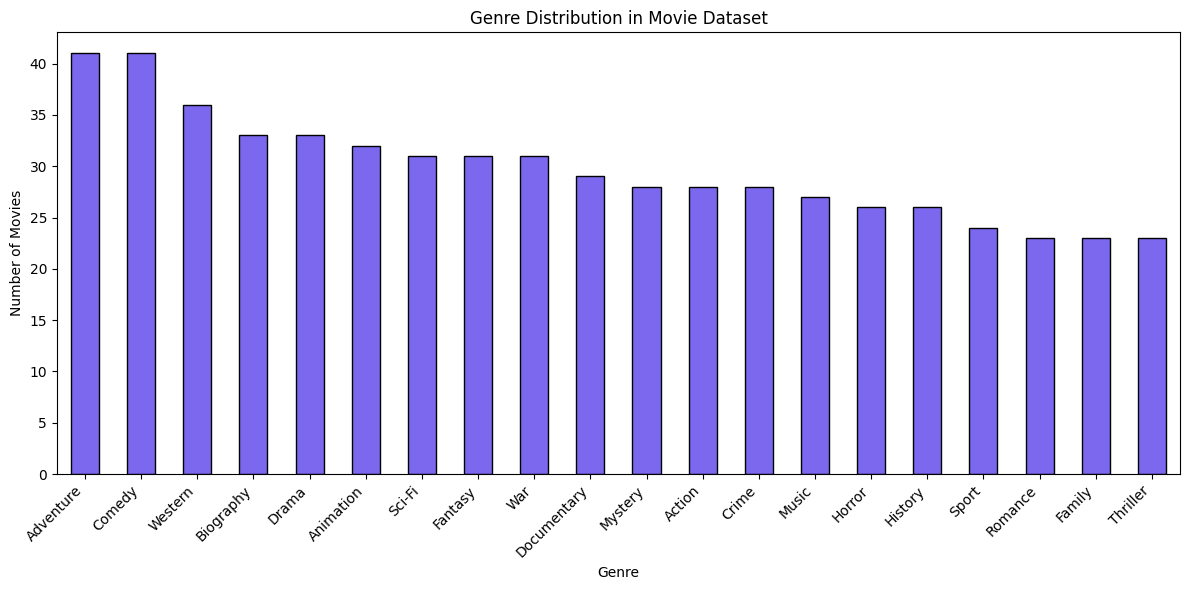

In [9]:
import matplotlib.pyplot as plt
import pandas as pd

# Muunna Spark DataFrame Pandas-muotoon
pdf = df.toPandas()

# Purkaa genre-listat yksittäisiksi riveiksi
genre_series = pdf['genres'].explode()

# Laske genrejen esiintymismäärät
genre_counts = genre_series.value_counts()

# Piirrä pylväsdiagrammi
plt.figure(figsize=(12,6))
genre_counts.plot(kind='bar', color='mediumslateblue', edgecolor='black')

plt.title("Genre Distribution in Movie Dataset")
plt.xlabel("Genre")
plt.ylabel("Number of Movies")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
